## **CLUSTERING**

- "Método no supervisado"
- A diferencia de **clasificación**, el **clustering** encuentra características similares entre distintos datos, formando así los grupos
- Permite agrupar de **manera no supervisada** (la propia máquina agrupa en función de características similares)

In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import distance
from operator import itemgetter
from IPython import display
import imageio
import os

In [2]:
df = pd.read_csv('./iris.csv')
features = df.columns[:-1]

### **METRICS**

In [3]:
# https://www.geeksforgeeks.org/calculate-the-euclidean-distance-using-numpy/
def euclidean(x1, x2):
    return distance.euclidean(x1, x2)

def chebychev(x1, x2):
    return distance.chebyshev(x1, x2)

def manhattan(x1, x2):
    return distance.cityblock(x1, x2)

### **CENTROID INITIALIZATION CRITERIA**

In [4]:
# https://neptune.ai/blog/k-means-clustering
def rand_centroids(data, k, distance):
    r, c = data.shape
    c_idx = np.random.choice(r, k)
    return data.iloc[c_idx].to_numpy()

def plus_plus(data, k, distance):
    centroids = [ data.sample(n=1).to_numpy().tolist()[0] ]
    for _ in range(k-1):
        c = centroids[-1]       # last centroid
        new_c = ([],-1)         # centroid, distance to c
        for i in range(len(data)):
            x_i = data.iloc[i].to_numpy().tolist()
            if x_i not in centroids:
                d =  pow(distance(c, x_i), 2)
                new_c = (x_i, d) if new_c[1] < d else new_c
        centroids.append(new_c[0])
    return np.array(centroids, dtype=object)         


In [5]:
m = {0:'v', 1:'o', 2:'P', 3: '^'}
co = {0:'blue', 1:'green', 2:'red', 3:'yellow'}
c = {'Setosa':'blue', 'Virginica':'green', 'Versicolor':'red'}

IMG_PATH = './img/'

In [6]:
class K_Means():
    def __init__(self, n, distance=euclidean, cc=rand_centroids):
        self.data = None
        self.n = n          # n° centroids
        self.K = None
        self.d = distance
        self.cc = cc        # centroid criteria

    def new_centroids(self, idx):
        new_K = [[] for _ in self.K]

        for i in range(len(self.K)):
            # obtener indices de todos los elementos pertenecientes al cluster i de la lista de indeices
            idx_curr_cluster = idx[idx['cluster'] == i]['idx'].to_list()
            # obtener elementos correspondientes al cluster i
            cluster_i_data = self.data.loc[idx_curr_cluster]
            
            if cluster_i_data.empty:
                new_K[i] = self.K[i]
            else:
                new_K[i] = self.data.loc[idx_curr_cluster].mean().to_numpy()
            
        return np.array(new_K, dtype=object)

    def label(self):
        """
        for each row of DataFrame 
            generate 3-tuple for each cluster
                [(row_id, cluster_i, distance), ...]
            get 2-tuple with the minimun distance
                (row_id, cluster_i)
        trasform list [(row_id, cluster_i), ...] to DataFrame and return it
        """
        idx = [
                min([(idx, i, self.d(self.K[i], self.data.iloc[idx].to_numpy())) for i in range(len(self.K))], key=itemgetter(2))[:-1] 
                for idx in range(len(self.data))
            ]
        return pd.DataFrame(idx, columns=['idx', 'cluster'])  

    def execute(self, d):
        self.data = d
        new_K = self.cc(self.data, self.n, self.d)

        i = 0
        idx = None
        while not (self.K == new_K).all():
            self.K = new_K
            idx = self.label()
            new_K = self.new_centroids(idx)
            i += 1
            self.save_plot(index=idx, kernels=pd.DataFrame(new_K, columns=features), it=i)
            
        print(f'\titerations {i}')
        self.build_gif(n_images=i)
        return new_K, idx

    def save_plot(self, index, kernels, it):
        plt.clf()
        for _ in range(len(self.data)):
            row = self.data.iloc[_]
            cluster = index[index['idx'] == _]['cluster'].values[0]
            plt.plot(
                row['petal.width'], row['petal.length'], 
                marker=m[cluster], linestyle="", c = co[cluster]
                )

        for _ in range(len(kernels)):
            k = kernels.iloc[_]
            plt.plot(k['petal.width'], k['petal.length'], c='orange', markersize=15, marker='o')
        plt.savefig(f'{IMG_PATH + str(it)}.png')
        # plt.show()
    
    # https://towardsdatascience.com/basics-of-gifs-with-pythons-matplotlib-54dd544b6f30
    def build_gif(self, n_images):        
        N_FRAMES = 10
        with imageio.get_writer(f'{IMG_PATH}K_Means.gif', mode='I') as writer:
            for _ in range(1, n_images+1):
                for f in range(N_FRAMES):
                    filename = f'{IMG_PATH + str(_)}.png'
                    image = imageio.imread(filename)
                    writer.append_data(image)

        for _ in range(1, n_images+1):
            os.remove(f'{IMG_PATH + str(_)}.png')

In [7]:
n = 3
data = df.copy()
d = data.iloc[:,:-1]  # df.sample(n=5).iloc[:,:-1]

In [8]:
k = K_Means(n, cc=plus_plus)

	iterations 7


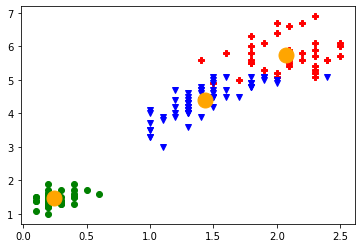

In [9]:
# print(d.shape)
kernels, clusters = k.execute(d)

In [10]:
# clusters

In [11]:
# kernels

In [12]:
df['cluster'] = clusters['cluster']
print(kernels)
kernels = pd.DataFrame(kernels, columns=features)

[[5.901612903225807 2.7483870967741932 4.393548387096775
  1.4338709677419355]
 [5.006 3.428 1.4620000000000002 0.24599999999999997]
 [6.8500000000000005 3.0736842105263156 5.742105263157893
  2.0710526315789473]]


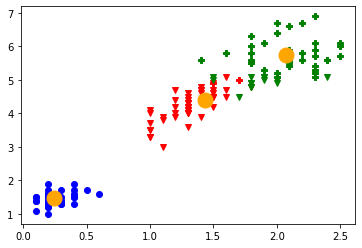

In [13]:
plt.clf()
for _ in range(len(df)):
    row = df.iloc[_]
    plt.plot(
        row['petal.width'], row['petal.length'], 
        marker=m[row['cluster']], linestyle="",
        c = c[row['variety']]
        )

for _ in range(len(kernels)):
    k = kernels.iloc[_]
    plt.plot(k['petal.width'], k['petal.length'], c='orange', markersize=15, marker='o')
plt.show()
